# Research Assistant

In [51]:
# from dotenv import load_dotenv
# load_dotenv(override=True)

In [52]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_community langchain_core tavily-python wikipedia

## Setup

In [53]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [54]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model='gpt-4o-mini',temperature=0)

## Generate Analysts: Human-In-The-Loop

Create analysts and review them using human-in-the-loop.

In [ ]:
from typing_extensions import TypedDict
from pydantic import BaseModel,Field
from IPython.display import Image, display

class Analyst(BaseModel):
    affiliation:str=Field(
        description='Primary affiliation of the analyst'
    )
    name:str=Field(
        description='Name of the analyst'
    )
    role:str=Field(
        description='Role of the analyst in the context of the topic'
    )
    description:str=Field(
        description="Description of the analyst's focus, concern and motives"
    )
    @property
    def persona(self)->str:
        return (
            f"Name: {self.name}\n"
            f"Role: {self.role}\n"
            f"Affiliation: {self.affiliation}\n"
            f"Description: {self.description}\n"
        )
    
class Perspectives(BaseModel):
    analysts:list[Analyst]=Field(
        description="Comprehensive list of analysts with their roles and affiliations."
    )

class GenerateAnalystState(TypedDict):
    topic:str #Research topic
    max_analysts:input # Number of analysts
    human_analyst_feedback:str # Human feedback
    analysts:list[Analyst] # Analyst asking questions

In [ ]:
from langgraph.graph import START,END,StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
from typing_extensions import Literal

analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

def create_analysts(state:GenerateAnalystState):

    """ create_analysts """

    topic=state['topic']
    max_analysts=state['max_analysts']
    human_analyst_feedback=state.get('human_analyst_feedback',"")

    # Enforce structured output
    structured_llm=llm.with_structured_output(Perspectives)

    # System message
    system_message=analyst_instructions.format(topic=topic,max_analysts=max_analysts,human_analyst_feedback=human_analyst_feedback)

    # Generate question 
    analysts=structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content='gnerate the set of analyst')])
    # print(analysts)

    # Write the list of analysis to state
    return {'analysts':analysts.analysts}

def human_feedback(state:GenerateAnalystState):
    """ No-op node that should be interrupted on """
    pass

def should_continue(state:GenerateAnalystState):
    """ Return the next node to execute """

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback',None)
    print(human_analyst_feedback)
    if human_analyst_feedback:
        return 'create_analysts'

    # Otherwise end
    return END


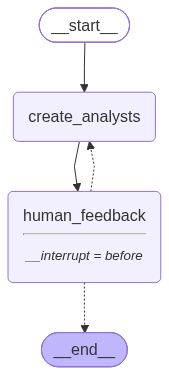

In [ ]:
# Add nodes and edges 
builder=StateGraph(GenerateAnalystState)
builder.add_node(create_analysts)
builder.add_node(human_feedback)

builder.add_edge(START,'create_analysts')
builder.add_edge('create_analysts','human_feedback')
builder.add_conditional_edges('human_feedback',should_continue,["create_analysts", END])

# Compile
memory=MemorySaver()
graph=builder.compile(interrupt_before=['human_feedback'],checkpointer=memory)

# view
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
# Input
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({'topic':topic,'max_analysts':max_analysts},thread,stream_mode='values'):
    # print(event)
    analysts=event.get('analysts','')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Description: {analyst.description}")
            print("-"*50)

Name: Dr. Emily Carter
Role: AI Framework Specialist
Affiliation: Tech Innovations Inc.
Description: Dr. Carter focuses on the technical advantages of LangGraph, analyzing its architecture and performance metrics compared to other frameworks. She is motivated by the potential for LangGraph to enhance AI development efficiency.
--------------------------------------------------
Name: Mr. James Liu
Role: Market Analyst
Affiliation: Future Insights Research Group
Description: Mr. Liu examines the market trends and adoption rates of LangGraph among businesses. His interest lies in understanding how LangGraph can provide competitive advantages and drive innovation in various industries.
--------------------------------------------------
Name: Ms. Sarah Thompson
Role: Ethics and Sustainability Advocate
Affiliation: Sustainable AI Initiative
Description: Ms. Thompson explores the ethical implications and sustainability of adopting LangGraph. She is concerned with how the framework can be util

In [ ]:
# Get state and look at next node
state=graph.get_state(thread)
state.next

('human_feedback',)

In [ ]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread,{'human_analyst_feedback':'add in someone from a startup to add and interprenuer perspective '},as_node='human_feedback')

add in someone from a startup to add and interprenuer perspective 


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1872d4-03a2-69e6-8002-19377247c65b'}}

In [61]:
state=graph.get_state(thread)
state.next

('create_analysts',)

In [ ]:
# Continue the graph execution
for event in graph.stream(None,thread,stream_mode='values'):
    analysts=event.get('analysts','')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Description: {analyst.description}")
            print("-"*50)

Name: Dr. Emily Carter
Role: AI Framework Specialist
Affiliation: Tech Innovations Inc.
Description: Dr. Carter focuses on the technical advantages of LangGraph, analyzing its architecture and performance metrics compared to other frameworks. She is motivated by the potential for LangGraph to enhance AI development efficiency.
--------------------------------------------------
Name: Mr. James Liu
Role: Market Analyst
Affiliation: Future Insights Research Group
Description: Mr. Liu examines the market trends and adoption rates of LangGraph among businesses. His interest lies in understanding how LangGraph can provide competitive advantages and drive innovation in various industries.
--------------------------------------------------
Name: Ms. Sarah Thompson
Role: Ethics and Sustainability Advocate
Affiliation: Sustainable AI Initiative
Description: Ms. Thompson explores the ethical implications and sustainability of adopting LangGraph. She is concerned with how the framework can be util

Name: Jordan Lee
Role: Startup Founder
Affiliation: Tech Startup Incubator
Description: Jordan is the founder of a tech startup focused on AI solutions. He is interested in how LangGraph can streamline agent development and enhance productivity in early-stage companies.
--------------------------------------------------
Name: Dr. Emily Chen
Role: AI Researcher
Affiliation: AI Research Institute
Description: Dr. Chen specializes in AI frameworks and their applications. She is focused on the technical benefits of LangGraph, particularly its scalability and integration capabilities.
--------------------------------------------------
Name: Michael Thompson
Role: Business Analyst
Affiliation: Business Consulting Firm
Description: Michael works with various enterprises to optimize their operations. He is exploring the strategic advantages of adopting LangGraph for improving decision-making processes and operational efficiency.
--------------------------------------------------


In [ ]:
state=graph.get_state(thread)
state.values

{'topic': 'The benefits of adopting LangGraph as an agent framework',
 'max_analysts': 3,
 'human_analyst_feedback': 'add in someone from a startup to add and interprenuer perspective ',
 'analysts': [Analyst(affiliation='Tech Startup Incubator', name='Jordan Lee', role='Startup Founder', description='Jordan is the founder of a tech startup focused on AI solutions. He is interested in how LangGraph can streamline agent development and enhance productivity in early-stage companies.'),
  Analyst(affiliation='AI Research Institute', name='Dr. Emily Chen', role='AI Researcher', description='Dr. Chen specializes in AI frameworks and their applications. She is focused on the technical benefits of LangGraph, particularly its scalability and integration capabilities.'),
  Analyst(affiliation='Business Consulting Firm', name='Michael Thompson', role='Business Analyst', description='Michael works with various enterprises to optimize their operations. He is exploring the strategic advantages of a

In [ ]:
# If we are satisfied, then we simply supply no feedback
graph.update_state(thread,{'human_analyst_feedback':None},as_node='human_feedback')

None


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1872d4-1b95-6b52-8004-3d3b13bda80d'}}

In [ ]:
# Continue the graph execution to end
for event in graph.stream(None,thread,stream_mode='updates'):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [66]:
final_state=graph.get_state(thread)
analysts=final_state.values.get('analysts','')

In [67]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Role: {analyst.role}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Description: {analyst.description}")
    print("-"*50)

Name: Jordan Lee
Role: Startup Founder
Affiliation: Tech Startup Incubator
Description: Jordan is the founder of a tech startup focused on AI solutions. He is interested in how LangGraph can streamline agent development and enhance productivity in early-stage companies.
--------------------------------------------------
Name: Dr. Emily Chen
Role: AI Researcher
Affiliation: AI Research Institute
Description: Dr. Chen specializes in AI frameworks and their applications. She is focused on the technical benefits of LangGraph, particularly its scalability and integration capabilities.
--------------------------------------------------
Name: Michael Thompson
Role: Business Analyst
Affiliation: Business Consulting Firm
Description: Michael works with various enterprises to optimize their operations. He is exploring the strategic advantages of adopting LangGraph for improving decision-making processes and operational efficiency.
--------------------------------------------------


## Conduct Interview

### Generate Question

The analyst will ask questions to the expert.

In [ ]:
from langgraph.graph import MessagesState
from typing import Annotated
from operator import add

class InterviewState(MessagesState):
    max_num_turns:int # Number turns of conversation
    context:Annotated[list[str],add] # Source docs
    analyst:Analyst # Analyst asking questions
    interview:str # Interview transcript
    sections:str # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query:str=Field(
        None,
        description='search query for retrieval'
    )    


In [ ]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

from pprint import pprint

def generate_question(state:InterviewState):
    """ Node to generate a question """

    # Get state
    analyst=state['analyst']
    messages=state['messages']

    # Generate question 
    system_message=question_instructions.format(goals=analyst.persona)
    question=llm.invoke([SystemMessage(content=system_message)]+messages)
    
    # pprint(question)

    # Write messages to state
    return {'messages':[question]}


### Generate Answer: Parallelization

The expert will gather information from multiple sources in parallel to answer questions.

In [ ]:
# Web search tool
from langchain_tavily import TavilySearch
tavily_search=TavilySearch(max_results=3)


In [ ]:
# Wikipedia search tool
import wikipedia

wikipedia.set_user_agent(
    "research-assistant/0.1 (you@example.com)"
)
from langchain_community.document_loaders import WikipediaLoader

Now, we create nodes to search the web and wikipedia.

We'll also create a node to answer analyst questions.

Finally, we'll create nodes to save the full interview and to write a summary ("section") of the interview.

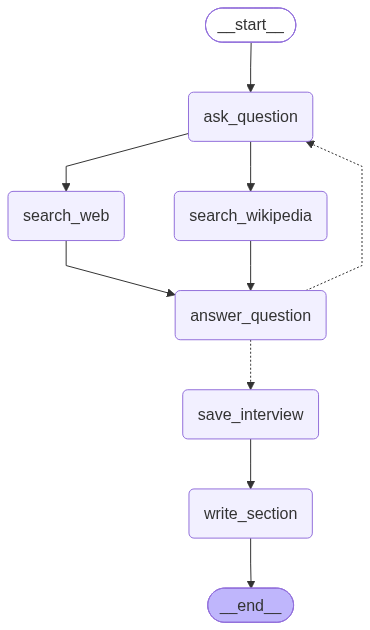

In [ ]:
from langchain_core.messages import get_buffer_string

# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

def search_web(state:InterviewState):

    """ Retrieve docs from web search """

    # Search query
    structure_llm=llm.with_structured_output(SearchQuery)
    search_query=structure_llm.invoke([search_instructions]+state['messages'])

    # Search
    data=tavily_search.invoke({'query':search_query.search_query})
    search_docs=data.get('results',[])
    # print('*'*100)
    # print(search_docs)
    # print('#'*100)
    # search_docs = tavily_search.invoke(search_query.search_query)

    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )
    return {'context':[formatted_search_docs]}

def search_wikipedia(state:InterviewState):
    
    """ Retrieve docs from wikipedia """

    # Search query
    structure_llm=llm.with_structured_output(SearchQuery)
    search_query=structure_llm.invoke([search_instructions]+state['messages'])

    # Search
    search_docs=WikipediaLoader(query=search_query.search_query,load_max_docs=2).load()
    # print('*'*100)
    # print(search_docs)
    # print('#'*100)

    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )
    return {"context": [formatted_search_docs]} 


answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

def generate_answers(state:InterviewState):
    analyst=state['analyst']
    messages=state['messages']
    context=state['context']
    system_message=answer_instructions.format(goals=analyst.persona,context=context)
    answer=llm.invoke([SystemMessage(content=system_message)]+messages)
    # pprint(answer)
    answer.name='expert'
    return {'messages':[answer]}

def save_interview(state:InterviewState):
    messages=state['messages']
    interview=get_buffer_string(messages)
    return {'interview':interview}

def route_messages(state:InterviewState,name:str='expert'):
    messages=state['messages']
    max_num_turns=state.get('max_num_turns',2)
    num_response=len([m for m in messages if isinstance(m,AIMessage) and m.name==name])
    if num_response>=max_num_turns:
        return 'save_interview'
    last_question=messages[-2]
    if 'Thank you so much for your help!' in last_question.content:
        return 'save_interview'
    return 'ask_question'

section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""


def write_section(state:InterviewState):
    interview=state['interview']
    context=state['context']
    analyst=state['analyst']
    system_message=section_writer_instructions.format(focus=analyst.description)
    section=llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"use this source to write your section: {context}")])
    # pprint(section)
    return {'sections':[section.content]}


interview_builder=StateGraph(InterviewState)
interview_builder.add_node('ask_question',generate_question)
interview_builder.add_node(search_web)
interview_builder.add_node(search_wikipedia)
interview_builder.add_node('answer_question',generate_answers)
interview_builder.add_node(save_interview)
interview_builder.add_node(write_section)

interview_builder.add_edge(START,'ask_question')
interview_builder.add_edge('ask_question','search_web')
interview_builder.add_edge('ask_question','search_wikipedia')
interview_builder.add_edge('search_web','answer_question')
interview_builder.add_edge('search_wikipedia','answer_question')
interview_builder.add_conditional_edges('answer_question',route_messages,['ask_question','save_interview'])
interview_builder.add_edge('save_interview','write_section')
interview_builder.add_edge('write_section',END)
memory=MemorySaver()
interview_graph=interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

display(Image(interview_graph.get_graph().draw_mermaid_png()))





In [73]:
analysts[0]

Analyst(affiliation='Tech Startup Incubator', name='Jordan Lee', role='Startup Founder', description='Jordan is the founder of a tech startup focused on AI solutions. He is interested in how LangGraph can streamline agent development and enhance productivity in early-stage companies.')

In [74]:
from IPython.display import Markdown 
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread={'configurable':{'thread_id':'1'}}
interview=interview_graph.invoke({'analyst':analysts[0],'messages':messages,'max_num_turns':2},thread)
# pprint(interview)
Markdown(interview['sections'][0])

## Streamlining AI Agent Development with LangGraph

### Summary
In the rapidly evolving landscape of artificial intelligence, startups are increasingly seeking frameworks that can enhance productivity and streamline the development of AI agents. LangGraph, an open-source framework developed by LangChain, stands out as a powerful tool for building, deploying, and managing complex generative AI workflows. Its unique graph-based architecture allows for intricate relationships between various components of AI workflows, making it particularly effective for tasks that require multi-step reasoning and backtracking. 

One of the most compelling insights from users is the framework's ability to handle complex reasoning tasks, which is often a challenge for simpler tools. Users have reported that once they grasp the node-edge structure of LangGraph, the process of building sophisticated agents becomes intuitive. This capability is especially beneficial for early-stage companies that need to develop agents capable of navigating multiple conversation threads or problem-solving scenarios. 

Moreover, LangGraph offers robust visual workflow management, which enhances observability and control over agent performance. This feature allows developers to monitor agent activities in real-time, facilitating quick adjustments and optimizations. The learning curve associated with LangGraph is acknowledged, but many users believe that the investment in mastering the framework pays off significantly in terms of the quality and reliability of the agents developed. 

In summary, LangGraph not only simplifies the development process but also empowers startups to create advanced AI solutions that can adapt and learn from complex interactions, ultimately driving productivity and innovation in the tech space.

### Sources
[1] https://community.latenode.com/t/what-are-the-main-advantages-of-choosing-langgraph-for-ai-agent-development/31000  
[2] https://www.langchain.com/langgraph  
[3] https://www.ibm.com/think/topics/langgraph  

### Parallelze interviews: Map-Reduce

We parallelize the interviews via the `Send()` API, a map step.

We combine them into the report body in a reduce step.

### Finalize

We add a final step to write an intro and conclusion to the final report.

In [76]:
class ResearchGraphState(TypedDict):
    topic:str
    max_analysts:int
    human_analyst_feedback:str
    analysts:list[Analyst]
    sections:Annotated[list[str],add]
    introduction:str
    content:str
    conclusion:str
    final_report:str

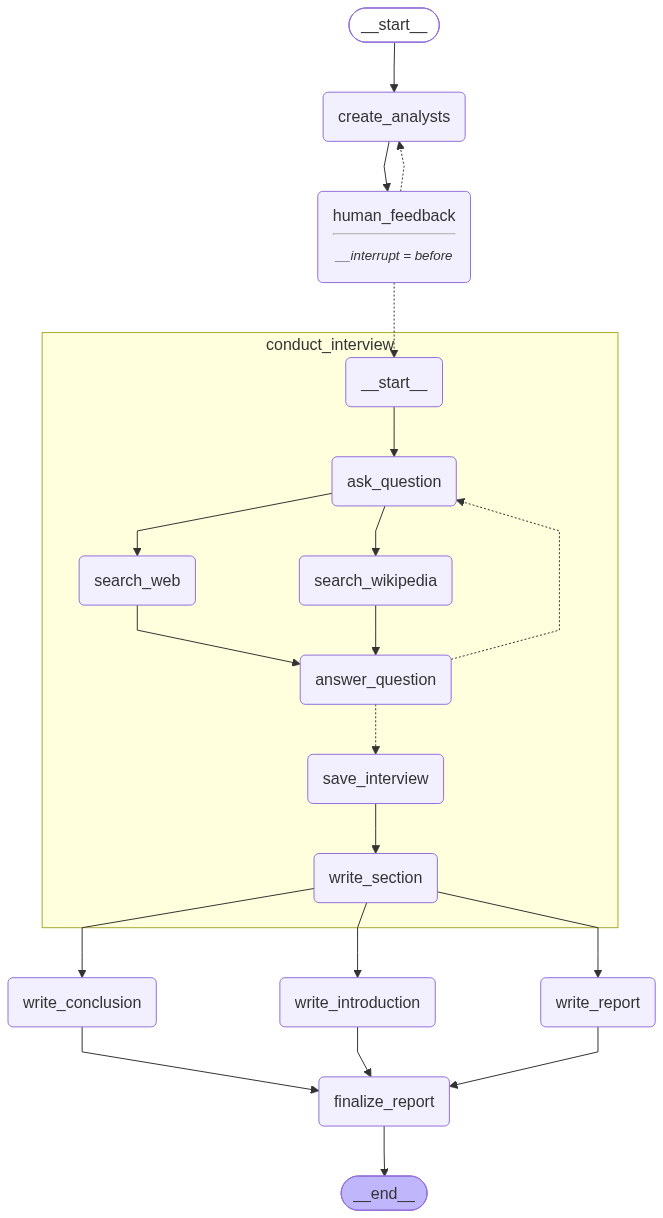

In [78]:
from langgraph.types import Send
def intialize_all_interview(state:ResearchGraphState):
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        return 'create_analysts'
    topic=state['topic']
    return [Send('conduct_interview',{'analyst':analyst,
                                      'messages':[HumanMessage(
                                          content=f"So you said you were writing an article on {topic}?")]}) for analyst in state['analysts']]

report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

def write_report(state:ResearchGraphState):
    sections=state['sections']
    topic=state['topic']
    formattted_str_sections="\n\n".join(sections)
    system_messages=report_writer_instructions.format(topic=topic,context=formattted_str_sections)
    report=llm.invoke([SystemMessage(content=system_messages)]+[HumanMessage(content=f"write a report based upon these memos")])
    return {'content':report.content}

intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

def write_introduction(state:ResearchGraphState):
    sections=state['sections']
    topic=state['topic']
    formattted_str_sections="\n\n".join(sections)
    instructions=intro_conclusion_instructions.format(topic=topic,formatted_str_sections=formattted_str_sections)
    intro=llm.invoke([SystemMessage(content=instructions)]+[HumanMessage(content=f"write the report introduction")])
    return {'introduction':intro.content}

def write_conclusion(state:ResearchGraphState):
    sections=state['sections']
    topic=state['topic']
    formattted_str_sections="\n\n".join(sections)
    instructions=intro_conclusion_instructions.format(topic=topic,formatted_str_sections=formattted_str_sections)
    conclusion=llm.invoke([SystemMessage(content=instructions)]+[HumanMessage(content=f"write the report conclusion")])
    return {'conclusion':conclusion.content}

def finalize_report(state:ResearchGraphState):
    content=state['content']
    content=content.removeprefix("## Insights").lstrip()
    sources=None
    if "\n## Sources\n" in content:
        content,sources=content.split("\n## Sources\n",maxsplit=1)

    final_report=(
        state['introduction']+"\n\n---\n\n"+content+"\n\n---\n\n"+state['conclusion']    
    )
    if sources:
        final_report+="\n\n## Sources\n"+sources
    return {'final_report':final_report}

builder=StateGraph(ResearchGraphState)
builder.add_node(create_analysts)
builder.add_node(human_feedback)
builder.add_node('conduct_interview',interview_builder.compile())
builder.add_node(write_conclusion)
builder.add_node(write_introduction)
builder.add_node(write_report)
builder.add_node(finalize_report)

builder.add_edge(START,'create_analysts')
builder.add_edge('create_analysts','human_feedback')
builder.add_conditional_edges('human_feedback',intialize_all_interview,['create_analysts','conduct_interview'])
builder.add_edge('conduct_interview','write_conclusion')
builder.add_edge('conduct_interview','write_introduction')
builder.add_edge('conduct_interview','write_report')
builder.add_edge('write_conclusion','finalize_report')
builder.add_edge('write_introduction','finalize_report')
builder.add_edge('write_report','finalize_report')
memory=MemorySaver()
graph=builder.compile(interrupt_before=['human_feedback'],checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))



In [79]:
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}
for event in graph.stream({'topic':topic,'max_analysts':max_analysts},thread,stream_mode='values'):
    # print(event)
    analysts=event.get('analysts','')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Description: {analyst.description}")
            print("-"*50)

Name: Dr. Emily Carter
Role: AI Framework Specialist
Affiliation: Tech Innovations Inc.
Description: Dr. Carter focuses on the technical advantages of LangGraph, analyzing its architecture and performance metrics compared to other frameworks. She aims to highlight how LangGraph can enhance AI model efficiency and scalability.
--------------------------------------------------
Name: Mr. James Liu
Role: Business Applications Analyst
Affiliation: Future AI Research Group
Description: Mr. Liu investigates the practical applications of LangGraph in various industries. His goal is to demonstrate the economic benefits and ROI of adopting LangGraph for businesses looking to integrate AI solutions.
--------------------------------------------------
Name: Dr. Sarah Thompson
Role: Ethics and Compliance Advisor
Affiliation: AI Ethics Consortium
Description: Dr. Thompson examines the ethical implications of using LangGraph as an agent framework. She is concerned with data privacy, bias in AI models

In [80]:
graph.update_state(thread, {"human_analyst_feedback": 
                                "Add in the CEO of gen ai native startup"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1872e2-9e70-6f64-8002-6f55cf3bccc5'}}

In [81]:
state=graph.get_state(thread)
state.next

('create_analysts',)

In [82]:
for event in graph.stream(None,thread,stream_mode='values'):
    # print(event)
    analysts=event.get('analysts','')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Description: {analyst.description}")
            print("-"*50)

Name: Dr. Emily Carter
Role: AI Framework Specialist
Affiliation: Tech Innovations Inc.
Description: Dr. Carter focuses on the technical advantages of LangGraph, analyzing its architecture and performance metrics compared to other frameworks. She aims to highlight how LangGraph can enhance AI model efficiency and scalability.
--------------------------------------------------
Name: Mr. James Liu
Role: Business Applications Analyst
Affiliation: Future AI Research Group
Description: Mr. Liu investigates the practical applications of LangGraph in various industries. His goal is to demonstrate the economic benefits and ROI of adopting LangGraph for businesses looking to integrate AI solutions.
--------------------------------------------------
Name: Dr. Sarah Thompson
Role: Ethics and Compliance Advisor
Affiliation: AI Ethics Consortium
Description: Dr. Thompson examines the ethical implications of using LangGraph as an agent framework. She is concerned with data privacy, bias in AI models

In [83]:
graph.update_state(thread, {"human_analyst_feedback": 
                                None}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1872e7-27af-65ec-8004-33cbe54ff04c'}}

In [ ]:
state=graph.get_state(thread)
state.next

In [84]:
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

--Node--
conduct_interview
--Node--
conduct_interview
--Node--
conduct_interview
--Node--
write_conclusion
--Node--
write_introduction
--Node--
write_report
--Node--
finalize_report


In [85]:
final_state=graph.get_state(thread)
report=final_state.values.get('final_report')
Markdown(report)

# Transforming AI Agent Development with LangGraph

## Introduction

In the fast-paced world of generative AI, the complexity of developing intelligent agents is on the rise. Traditional frameworks often falter in managing intricate workflows and maintaining context. Enter LangGraph, a revolutionary agent framework that leverages a graph-based architecture to simplify the creation of sophisticated, stateful multi-agent applications. This report explores LangGraph's key advantages, including automatic state management, visual workflow design, and robust error recovery mechanisms. We will also examine its scalability and real-time response capabilities, showcasing how LangGraph empowers organizations to unlock new business potential and enhance operational efficiency in AI development.

---

LangGraph is emerging as a transformative framework for developing AI agents, addressing the complexities and scalability demands of modern artificial intelligence applications. Its graph-based architecture allows developers to create sophisticated, stateful multi-agent applications with ease, significantly enhancing the capabilities of AI systems compared to traditional linear coding frameworks.

One of the standout features of LangGraph is its automatic state management, which ensures that agents can track and retain context across multiple interactions. This capability is crucial for applications requiring nuanced decision-making and real-time data synthesis, as it allows agents to build upon previous interactions to make informed decisions. The framework's support for cyclical workflows enables iterative refinement of agent actions, which is essential for managing complex tasks that require backtracking and multi-step reasoning.

LangGraph's visual workflow management simplifies the development process by allowing developers to construct agent behaviors graphically. This not only enhances the understanding of complex applications but also aids in debugging, making it easier to manage intricate workflows. The framework's error recovery mechanisms are particularly noteworthy; when agents encounter issues, developers can set fallback paths to prevent complete system failures, thereby enhancing reliability and user experience.

The responsiveness of LangGraph, with its real-time streaming capabilities, provides immediate feedback to users, contrasting sharply with the loading screens typical of other frameworks. This feature is vital for applications in customer support and other interactive environments, where user satisfaction is paramount. Additionally, LangGraph's integration with existing tools and APIs facilitates seamless deployment in production environments, making it an attractive option for businesses looking to innovate without overhauling their current systems.

Organizations across various sectors, including real estate, fintech, and healthcare, are successfully implementing LangGraph to enhance operational capabilities. Case studies reveal significant improvements in task efficiency and accuracy, with companies like AppFolio and Klarna utilizing LangGraph as a copilot for domain-specific tasks. Furthermore, organizations such as Athena Intelligence and OpenRecovery have reported enhanced research and summarization capabilities, leading to better-informed decision-making processes.

As AI applications grow in sophistication, the need for frameworks that can scale effectively becomes paramount. LangGraph's architecture is designed for scalability, accommodating distributed execution and complex coordination patterns, making it a robust choice for high-complexity AI systems. This positions LangGraph as a complementary tool within the LangChain ecosystem, allowing developers to transition between frameworks based on their project needs and future scalability goals.

In summary, LangGraph not only addresses the limitations of traditional frameworks but also empowers developers to create more capable, flexible, and reliable AI systems. Its unique features and capabilities pave the way for advancements in AI research and development, unlocking significant business potential and competitive advantages in the marketplace.


---

## Conclusion

LangGraph represents a significant advancement in the development of AI agents, addressing the complexities and scalability challenges faced by traditional frameworks. Its graph-based architecture facilitates the creation of sophisticated, stateful multi-agent applications, enabling developers to manage complex workflows with ease. The automatic state management and visual workflow capabilities enhance reliability and reduce coding overhead, while error recovery mechanisms ensure smoother user experiences. As demonstrated through various case studies, organizations across multiple sectors are leveraging LangGraph to unlock operational efficiencies and drive innovation. By adopting LangGraph, businesses can position themselves at the forefront of AI development, paving the way for enhanced productivity and competitive advantage.

## Sources
[1] https://community.latenode.com/t/what-are-the-main-advantages-of-choosing-langgraph-for-ai-agent-development/31000  
[2] https://medium.com/@ken_lin/langgraph-a-framework-for-building-stateful-multi-agent-llm-applications-a51d5eb68d03  
[3] https://medium.com/@mahartariq/building-multi-agent-applications-with-langgraph-a-powerful-framework-for-ai-agents-9e362cf32c27  
[4] https://www.scalablepath.com/ai/langgraph  
[5] https://docs.langchain.com/oss/python/langgraph/case-studies  
[6] https://thirdeyedata.ai/data-ai-industry-insights/a-comparative-study-between-langgraph-and-langchain-for-enterprise-ai-development  
[7] https://www.truefoundry.com/blog/langchain-vs-langgraph  
[8] https://ardor.cloud/blog/comparison-of-scalable-agent-frameworks  